<a href="https://colab.research.google.com/github/faddednatasha/Loan-Default-Risk-Prediction-System/blob/main/Loan_Default_Risk_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,roc_auc_score,confusion_matrix,precision_score,recall_score

# **DATA CLEANING**

In [8]:
data=pd.read_csv('/content/Loan_Entries_1500.csv')
df=pd.DataFrame(data)
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Co-applicant_Income,Loan_Amount,Term,Credit_History,Property_Area,Status
0,LP10000,Male,No,1,Not Graduate,No,1753,3785,136,360,1,Semiurban,Y
1,LP10001,Male,No,2,Graduate,No,1239,1538,73,360,1,Semiurban,Y
2,LP10002,Male,Yes,0,Graduate,No,994,0,23,360,1,Urban,Y
3,LP10003,Male,Yes,2,Graduate,No,6018,0,194,360,1,Semiurban,Y
4,LP10004,Male,No,1,Graduate,No,13674,4401,706,360,1,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,LP11495,Male,No,0,Graduate,No,4146,4398,213,360,0,Rural,N
1496,LP11496,Male,No,0,Graduate,Yes,6764,0,242,360,1,Semiurban,Y
1497,LP11497,Male,Yes,2,Graduate,No,19445,2382,504,360,1,Semiurban,Y
1498,LP11498,Male,Yes,0,Graduate,No,2196,0,80,180,1,Rural,Y


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Loan_ID              1500 non-null   object
 1   Gender               1500 non-null   object
 2   Married              1500 non-null   object
 3   Dependents           1500 non-null   object
 4   Education            1500 non-null   object
 5   Self_Employed        1500 non-null   object
 6   Applicant_Income     1500 non-null   int64 
 7   Co-applicant_Income  1500 non-null   int64 
 8   Loan_Amount          1500 non-null   int64 
 9   Term                 1500 non-null   int64 
 10  Credit_History       1500 non-null   int64 
 11  Property_Area        1500 non-null   object
 12  Status               1500 non-null   object
dtypes: int64(5), object(8)
memory usage: 152.5+ KB


In [10]:
df['Dependents'].value_counts()

,count
Dependents,
0,743
2,320
1,289
3+,148


In [11]:
df['Credit_History'].value_counts()

,count
Credit_History,
1,1291
0,209


In [12]:
df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'].fillna(df['Credit_History'].mode()[0])

,Credit_History
0,1
1,1
2,1
3,1
4,1
...,...
1495,0
1496,1
1497,1
1498,1


In [13]:
df=df.dropna()

In [14]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Applicant_Income', 'Co-applicant_Income',
       'Loan_Amount', 'Term', 'Credit_History', 'Property_Area', 'Status'],
      dtype='object')

# **DATA PREPROCESSING**

In [15]:
# Checking the Outlier percentage in every numerical column
def calculate_outlier():
    cols=['Applicant_Income', 'Co-applicant_Income', 'Loan_Amount',
       'Term']
    for col in cols:
        IQR=df[col].quantile(0.75)-df[col].quantile(0.25)
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        lower_outlier_threshold=Q1-(1.5*IQR)
        upper_outlier_threshold=Q3+(1.5*IQR)
        outliers=[x for x in df[col] if x<lower_outlier_threshold or x>upper_outlier_threshold]
        no_of_outlier=(len(outliers)/len(df[col]))*100
        print(f"In the Column {col},There are {no_of_outlier}% Outliers are Present\n")

/tmp/ipython-input-3426926600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


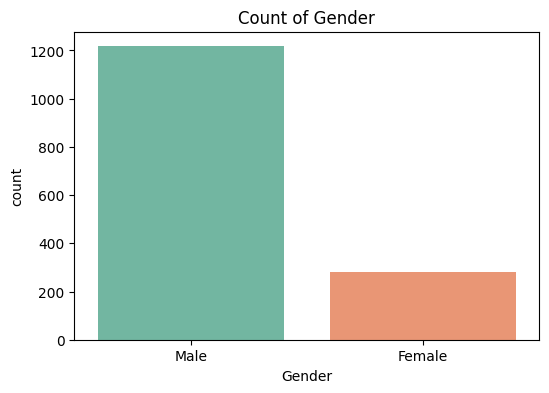

/tmp/ipython-input-3426926600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


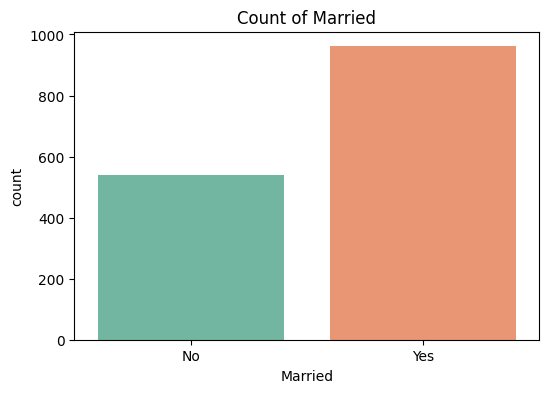

/tmp/ipython-input-3426926600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


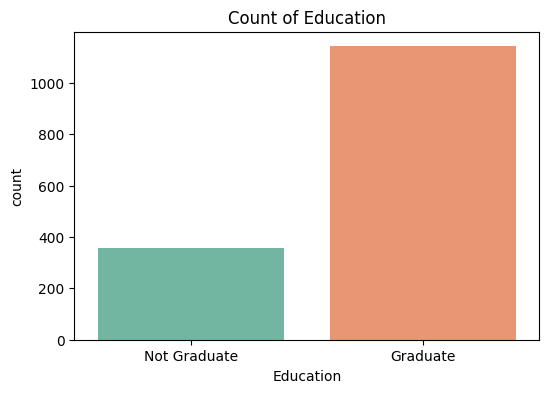

/tmp/ipython-input-3426926600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


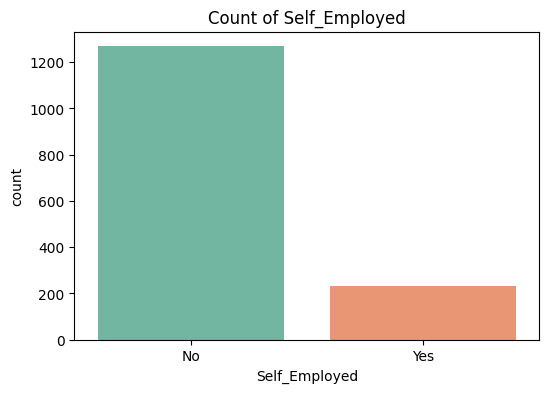

/tmp/ipython-input-3426926600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


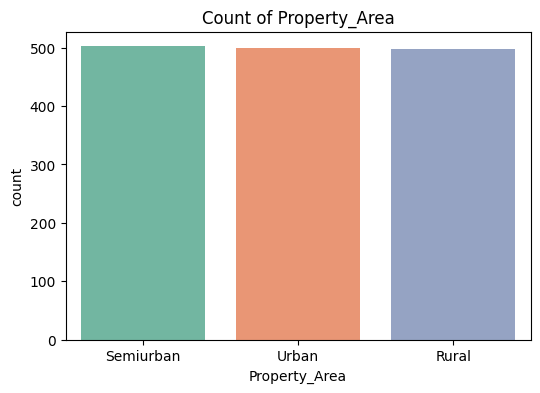

/tmp/ipython-input-3426926600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


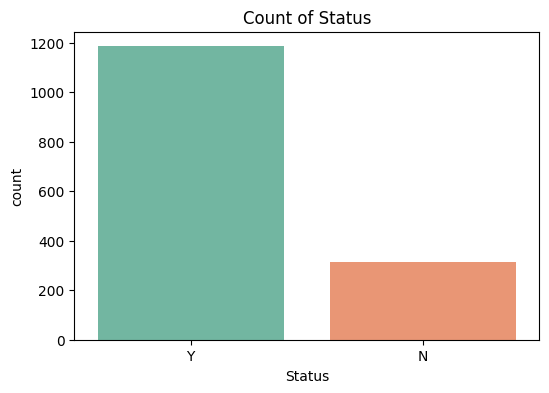

In [16]:
# Bar plots for categorical features
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Status']
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, palette="Set2")
    plt.title(f"Count of {col}")
    plt.show()

<Figure size 2000x2000 with 0 Axes>

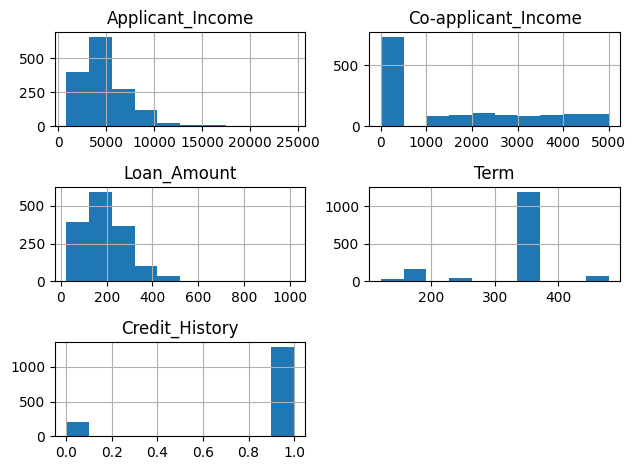

In [17]:
plt.figure(figsize=(20,20))
df.hist()
plt.tight_layout()

In [18]:
calculate_outlier()

In the Column Applicant_Income,There are 3.2% Outliers are Present

In the Column Co-applicant_Income,There are 0.0% Outliers are Present

In the Column Loan_Amount,There are 2.1333333333333333% Outliers are Present

In the Column Term,There are 20.733333333333334% Outliers are Present



<Axes: >

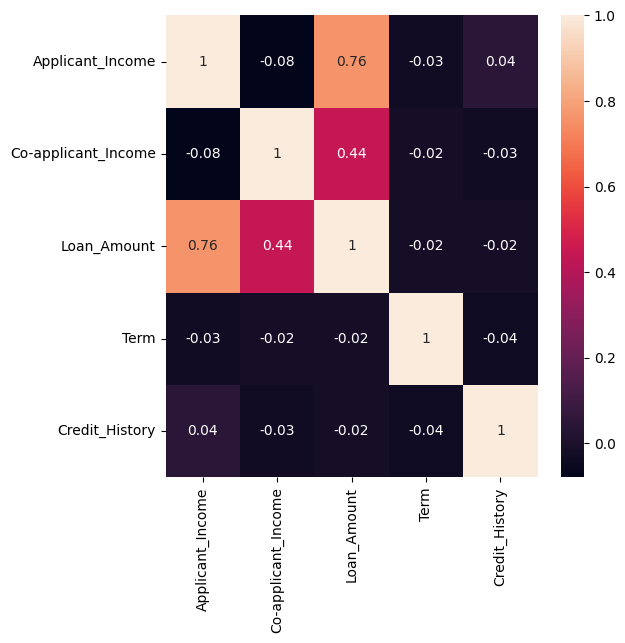

In [19]:
# Correlation
plt.figure(figsize=(6,6))
sns.heatmap(round(df.corr(numeric_only=True),2),annot=True)

In [20]:
cols=['Gender', 'Married', 'Dependents', 'Education','Self_Employed','Credit_History', 'Property_Area', 'Status']
Le=LabelEncoder()
for col in cols:
    df[col]=Le.fit_transform(df[col])

In [21]:
sc= StandardScaler()
cols = ['Applicant_Income', 'Co-applicant_Income', 'Loan_Amount', 'Term']

df[cols] = sc.fit_transform(df[cols])

/tmp/ipython-input-3354360266.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=col, data=df, palette="Set3")


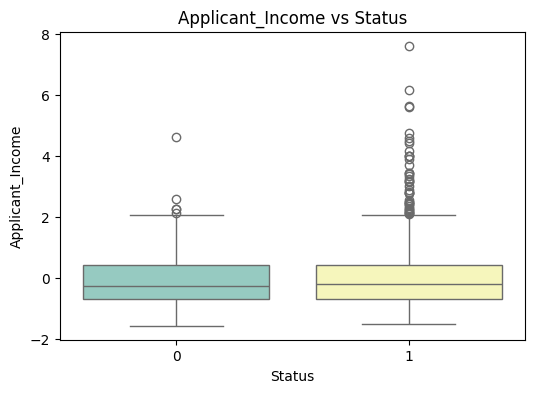

/tmp/ipython-input-3354360266.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=col, data=df, palette="Set3")


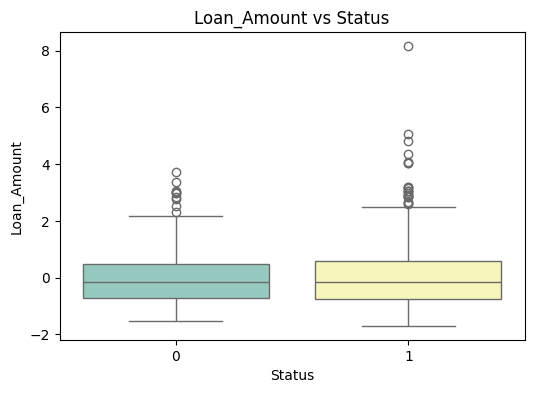

In [22]:
#Boxplots for numerical vs Loan_Status
for col in ['Applicant_Income', 'Loan_Amount']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Status', y=col, data=df, palette="Set3")
    plt.title(f"{col} vs Status")
    plt.show()

In [40]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Co-applicant_Income,Loan_Amount,Term,Credit_History,Property_Area,Status
0,LP10000,1,0,1,1,0,-1.219814,1.304194,-0.576980,0.310194,1,1,1
1,LP10001,1,0,2,0,0,-1.418440,-0.001731,-1.201332,0.310194,1,1,1
2,LP10002,1,1,0,0,0,-1.513117,-0.895595,-1.696849,0.310194,1,2,1
3,LP10003,1,1,2,0,0,0.428325,-0.895595,-0.002180,0.310194,1,1,1
4,LP10004,1,0,1,0,0,3.386860,1.662204,5.071914,0.310194,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,LP11495,1,0,0,0,0,-0.295078,1.660461,0.186116,0.310194,0,0,0
1496,LP11496,1,0,0,0,1,0.716605,-0.895595,0.473516,0.310194,1,1,1
1497,LP11497,1,1,2,0,0,5.616967,0.488790,3.070026,0.310194,1,1,1
1498,LP11498,1,1,0,0,0,-1.048624,-0.895595,-1.131959,-2.164761,1,0,1


# **MODEL TRAINING**

In [24]:

X = df.drop(['Loan_ID', 'Status'], axis=1)
y = df['Status']

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# **LOGISTIC REGRESSION**

In [26]:
model1=LogisticRegression()

In [27]:
model1.fit(X_test,y_test)

LogisticRegression()

In [28]:
y_pred=model1.predict(X_test)

In [29]:
m1_accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy Score: {m1_accuracy}")

Accuracy Score: 0.9066666666666666


In [30]:
m1_precision=precision_score(y_test,y_pred)
print(f"Precision Score:{m1_precision}")

Precision Score:0.9115384615384615


In [31]:
m1_recall=recall_score(y_test,y_pred)
print(f"Recall Score:{m1_recall}")

Recall Score:0.9793388429752066


In [32]:
m1_roc_auc=roc_auc_score(y_test,y_pred)
print(f"Roc Auc: {m1_roc_auc}")

Roc Auc: 0.7913935594186378


In [33]:
m1_confusion_mat=confusion_matrix(y_test,y_pred)
print(f"Confusion Matrix: \n {m1_confusion_mat}")

Confusion Matrix: 
 [[ 35  23]
 [  5 237]]


# **RANDOM FOREST**

In [34]:
model2=RandomForestClassifier(random_state=42,n_estimators=100,max_depth=5)

In [35]:
model2.fit(X_test,y_test)

RandomForestClassifier(max_depth=5, random_state=42)

In [36]:
y_predm2=model2.predict(X_test)

In [37]:
m2_accuracy=accuracy_score(y_test,y_predm2)
print(f"Accuracy Score: {m2_accuracy}")

Accuracy Score: 0.9233333333333333


In [38]:
m2_precision=precision_score(y_test,y_predm2)
print(f"Precision Score:{m2_precision}")

Precision Score:0.9132075471698113


In [39]:
m2_recall=recall_score(y_test,y_predm2)
print(f"Recall Score:{m2_recall}")

Recall Score:1.0


In [40]:
m2_roc_auc=roc_auc_score(y_test,y_predm2)
print(f"Roc Auc: {m2_roc_auc}")

Roc Auc: 0.8017241379310345


In [41]:
m2_confusion_mat=confusion_matrix(y_test,y_predm2)
print(f"Confusion Matrix: \n {m2_confusion_mat}")

Confusion Matrix: 
 [[ 35  23]
 [  0 242]]


# **COMPARING LOGISTIC AND RANDOM FOREST MODELS**

In [42]:
compare = [
    ['Model', 'Accuracy Score', 'Precision Score', 'Recall', 'ROC AUC', 'Confusion Matrix'],
    ['Logistic Regression', m1_accuracy, m1_precision, m1_recall, m1_roc_auc, m1_confusion_mat],
    ['Random Forest', m2_accuracy, m2_precision, m2_recall, m2_roc_auc, m2_confusion_mat]
]

compare_df = pd.DataFrame(compare[1:], columns=compare[0])
compare_df

,Model,Accuracy Score,Precision Score,Recall,ROC AUC,Confusion Matrix
0,Logistic Regression,0.906667,0.911538,0.979339,0.791394,"[[35, 23], [5, 237]]"
1,Random Forest,0.923333,0.913208,1.000000,0.801724,"[[35, 23], [0, 242]]"


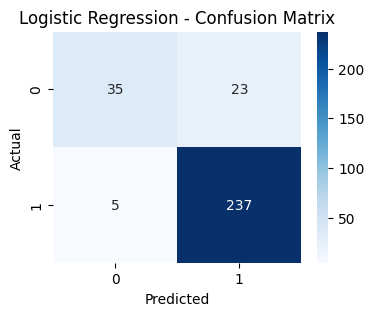

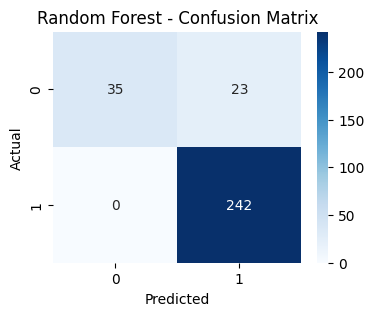

In [43]:
# Confusion Matrices
models = [("Logistic Regression", y_pred), ("Random Forest", y_predm2)]
for name, y_pred in models:
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


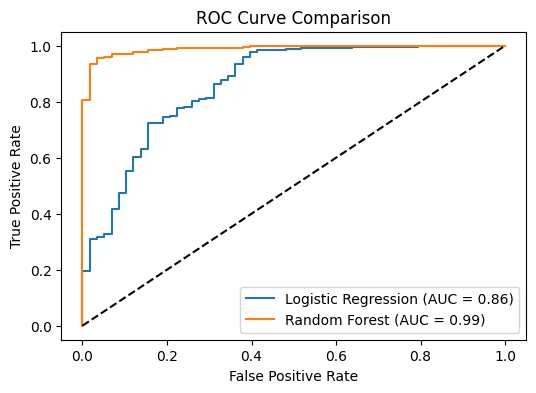

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for Logistic Regression
y_pred_proba_log = model1.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_pred_proba_log)
roc_auc_log = roc_auc_score(y_test, y_pred_proba_log)

# Get predicted probabilities for Random Forest
y_pred_proba_rf = model2.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()